In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import time
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import pickle as pkl
import networkx as nx
import matplotlib.pyplot as plt

from scipy.stats import rv_histogram

import src
from src.reload import deep_reload

In [2]:
outline = gpd.read_file('../google_charger_data/Data/State/tl_2023_us_state.shp')

In [3]:
'''
Loading Atlas
'''

atlas = src.graph.graph_from_json('Inputs/reduced_atlas.json')

In [25]:
'''
Loading stations
'''

graph = src.graph.graph_from_json('Outputs/graph.json')

In [9]:
'''
Adding adjacency
'''
deep_reload(src)

depots = [k for k, v in graph._node.items() if v['network'] == 'Depot']

kw = {
    'maximum_cost': 20e3,
    'maximum_depth': 20e3,
    'depots': depots,
    'update': True,
    'progress_bar': {
        'freq': 100,
    },
}

graph = src.adjacency.adjacency(atlas, graph, **kw)

 [---->] (11346/11346) 100.00%, 600.82 it/s, 18.89 s elapsed, 0.00 s remaining

In [10]:
graph.number_of_nodes(), graph.number_of_edges()

(13310, 4220058)

In [43]:
graph.number_of_nodes(), graph.number_of_edges()

(13310, 4302870)

In [11]:
'''
Saving stations
'''

src.graph.graph_to_json(graph, 'Outputs/graph_adj.json')

In [12]:
'''
Loading stations
'''

graph = src.graph.graph_from_json('Outputs/graph_adj.json')

In [39]:
'''
Loading visited stations
'''

visited = pd.read_csv('Inputs/visited_07_28.csv')

visited_locations = visited.id.to_list()

In [40]:
'''
Loading groups
'''
deep_reload(src)

groups, counts = src.sample.load_groups('Inputs/sampling_rules.csv')

graph = src.sample.assign_groups(graph, groups)

totals = {k: 0 for k in counts.keys()}

for source, node in graph._node.items():

    if node['group'] is not None:

        totals[node['group']] += 1

adjusted_counts = {k: min([totals[k], counts[k]]) for k in totals.keys()}

In [41]:
depots

[1, 2, 3]

In [42]:
'''
Building the cost matrix
'''
deep_reload(src)

depots = [k for k, v in graph._node.items() if v['network'] == 'Depot']

graph = src.sample.station_costs(graph, atlas, depots, objective = 'time')

for source, node in graph._node.items():
    
    if source in visited_locations:

        node['depot_costs'] = {k: 0 for k, v in node['depot_costs'].items()}
        node['visited'] = True

    else:

        node['visited'] = False

In [43]:
'''
Optimizing the sample
'''
deep_reload(src)

opt = src.sample.Optimization(graph, adjusted_counts)

solver_kwargs = {'_name': 'cbc', 'executable': 'src/cbc'}
# solver_kwargs = {'_name': 'appsi_highs'}

opt.solve(**solver_kwargs)

Problem Built: 1.2463963031768799
Problem Solved: 3.2933766841888428
Results Collected: 0.04915475845336914


In [44]:
'''
Making subgraphs
'''
deep_reload(src)

subgraphs = src.sample.subgraphs(graph, opt.assignment)

In [45]:
subgraphs

{1: <networkx.classes.graph.Graph at 0x7ff8211f9160>,
 2: <networkx.classes.graph.Graph at 0x7ff81f164fb0>,
 3: <networkx.classes.graph.Graph at 0x7ff8210a41a0>}

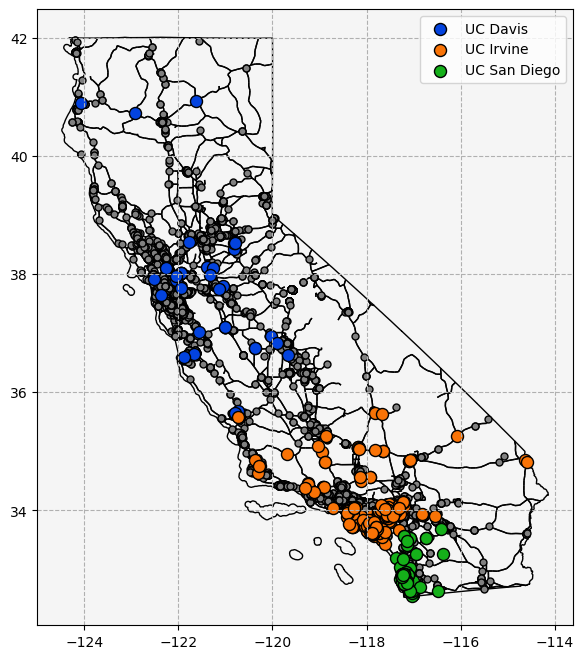

In [46]:
fig, ax = plt.subplots(figsize = (8, 8))

kw = {
    'fc': 'none',
    'ec': 'k',
}

_ = outline[outline['STATEFP'] == '06'].plot(ax = ax, **kw)

kw = {
    'edges': {
        'plot':{
            'lw': 1,
            'color': 'k',
            'zorder': 0,
        },
    },
}

plots = src.figures.plot_graph(atlas, ax = ax, **kw)

kw = {
    'nodes': {
        'field': 'assignment',
        'plot': {
            's': 25,
            'fc': 'gray',
            'ec': 'k',
            'zorder': 1,
        },
    },
}

plots = src.figures.plot_graph(graph, ax = ax, **kw)

colors = ['xkcd:green', 'xkcd:orange', 'xkcd:blue']
labels = list(np.flip(
    [v['name'] for k, v in graph._node.items() if v['network'] == 'Depot']
))

for depot, subgraph in subgraphs.items():

    kw = {
    'nodes': {
        'plot': {
            's': 75,
            'ec': 'k',
            'zorder': 1,
            'fc': colors.pop(),
            'label': labels.pop(),
            },
        },
    }
        
    plots = src.figures.plot_graph(subgraph, ax = ax, **kw)

kw = {
    'facecolor': 'whitesmoke',
}

ax.set(**kw)

kw = {
    'ls': 'dashed',
}

ax.grid(**kw)

ax.legend()

# fig.savefig('new_sample.png', bbox_inches = 'tight', dpi = 300)

In [47]:
[(s.number_of_nodes(), s.number_of_edges()) for s in subgraphs.values()]

[(40, 0), (686, 0), (167, 0)]

In [48]:
'''
Adding adjacency
'''
deep_reload(src)

kw = {
    'maximum_cost': 300e3,
    'maximum_depth': 300e3,
    'depots': list(subgraphs.keys()),
}

for depot, subgraph in subgraphs.items():

    subgraph = src.adjacency.adjacency(atlas, subgraph, **kw)
    # break

 [---------->] (167/167) 100.00%, 56.45 it/s, 2.98 s elapsed, 0.00 s remaining

In [49]:
for depot, subgraph in subgraphs.items():

    src.graph.graph_to_json(subgraph, f"Outputs/graphs/subgraph_{depot}.json")

In [50]:
[(s.number_of_nodes(), s.number_of_edges()) for s in subgraphs.values()]

[(40, 630), (686, 232721), (167, 14028)]

In [43]:
len(subgraphs[1]._adj[1])

368

In [44]:
len(subgraphs[2]._adj[2])

895

In [46]:
list(subgraphs.keys())

[1, 2]

In [43]:
[(s.number_of_nodes(), s.number_of_edges()) for s in subgraphs.values()]

[(584, 120717), (1041, 510298)]